In [ ]:
# Cài đặt các thư viện cần thiết
!pip install torch torchvision pandas nibabel SimpleITK scikit-image

In [ ]:
import os
import time
import random
import zipfile
import shutil
import gdown
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Tải file từ Google Drive
url = "https://drive.google.com/uc?id=1YHVACL9CIhVFrZ-MnhuDoYNdQBH-lkGJ"
output = "/kaggle/working/data_processed.zip"
gdown.download(url, output, quiet=False)

# Giải nén file
extract_dir = "/kaggle/working/"
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Đã giải nén file data_processed.zip")


In [2]:
# Cài đặt các thư viện cần thiết
!pip install torch torchvision pandas nibabel SimpleITK scikit-image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import random
import SimpleITK as sitk
from skimage import morphology, measure

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Giải phóng VRAM
torch.cuda.empty_cache()

import torch
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import shutil

# Đọc file participants.xlsx
participants_file = "/kaggle/input/cam-can/data-20250425T101912Z-002/data/participants.xlsx"
participants_df = pd.read_excel(participants_file)

# Tạo dictionary ánh xạ subject_id
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }
print(f"Tổng số subject trong participants.xlsx: {len(subject_info)}")

# Thu thập danh sách file .nii.gz từ các thư mục data-20250425T101912Z-001 đến 006
data_base_dir = "/kaggle/input/cam-can"
file_list = []
ages = []
genders = []
missing_subjects = []

# Duyệt qua các thư mục data-20250425T101912Z-00X
for data_part in [f"data-20250425T101912Z-00{i}" for i in range(1, 7)]:
    data_part_path = os.path.join(data_base_dir, data_part, "data")
    if not os.path.exists(data_part_path):
        print(f"Không tìm thấy thư mục: {data_part_path}")
        continue
    for sub_dir in os.listdir(data_part_path):
        if not sub_dir.startswith('sub-BrainAge'):
            continue
        sub_dir_path = os.path.join(data_part_path, sub_dir, "anat")
        if not os.path.exists(sub_dir_path):
            print(f"Không tìm thấy thư mục anat: {sub_dir_path}")
            continue
        for file in os.listdir(sub_dir_path):
            if file.endswith('.nii.gz'):
                file_path = os.path.join(sub_dir_path, file)
                file_list.append(file_path)
                subject_id = sub_dir
                if subject_id in subject_info:
                    age = subject_info[subject_id]['age']
                    gender = subject_info[subject_id]['gender']
                    ages.append(age)
                    genders.append(gender)
                else:
                    missing_subjects.append((file_path, subject_id))

print(f"Tổng số file .nii.gz tìm thấy: {len(file_list)}")
print(f"Số file không tìm thấy thông tin trong participants.xlsx: {len(missing_subjects)}")
if missing_subjects:
    print("Các subject không có thông tin:")
    for file_path, subject_id in missing_subjects[:5]:  # In tối đa 5 ví dụ
        print(f" - {subject_id}: {file_path}")
    if len(missing_subjects) > 5:
        print(f" ... và {len(missing_subjects) - 5} subject khác.")

Tổng số subject trong participants.xlsx: 4950
Tổng số file .nii.gz tìm thấy: 0
Số file không tìm thấy thông tin trong participants.xlsx: 0


In [ ]:
import torch
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import shutil

# Đọc file participants.xlsx
participants_file = "/kaggle/input/cam-can/data-20250425T101912Z-002/data/participants.xlsx"
participants_df = pd.read_excel(participants_file)

# Xóa sub-BrainAge019983 và sub-BrainAge005600 khỏi participants.xlsx
subjects_to_remove = ['sub-BrainAge019983', 'sub-BrainAge005600']
participants_df = participants_df[~participants_df['subject_id'].isin(subjects_to_remove)]
# Lưu participants.xlsx mới
filtered_participants_file = "/kaggle/working/participants_filtered.xlsx"
participants_df.to_excel(filtered_participants_file, index=False)
print(f"Đã xóa {len(subjects_to_remove)} subject khỏi participants.xlsx. File mới lưu tại: {filtered_participants_file}")

# Tạo dictionary ánh xạ subject_id
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }
print(f"Tổng số subject trong participants.xlsx (sau lọc): {len(subject_info)}")

# Thu thập danh sách file .nii
data_base_dir = "/kaggle/input/cam-can"
file_list = []
ages = []
genders = []
missing_subjects = []

for sub_dir in os.listdir(data_base_dir):
    sub_dir_path = os.path.join(data_base_dir, sub_dir, "data")
    if not os.path.exists(sub_dir_path):
        continue
    
    for root, dirs, files in os.walk(sub_dir_path):
        for file in files:
            if file.endswith('.nii'):
                file_path = os.path.join(root, file)
                parent_dir = os.path.basename(os.path.dirname(file_path))
                subject_id = parent_dir.split('_T1w')[0]
                if subject_id in subjects_to_remove:
                    continue  # Bỏ qua subject lỗi
                file_list.append(file_path)
                if subject_id in subject_info:
                    age = subject_info[subject_id]['age']
                    gender = subject_info[subject_id]['gender']
                    ages.append(age)
                    genders.append(gender)
                else:
                    missing_subjects.append((file_path, subject_id))

print(f"Tổng số file .nii tìm thấy: {len(file_list)}")
print(f"Số file không tìm thấy thông tin trong participants.xlsx: {len(missing_subjects)}")
if missing_subjects:
    print("Các subject không có thông tin:")
    for file_path, subject_id in missing_subjects[:5]:
        print(f" - {subject_id}: {file_path}")
    if len(missing_subjects) > 5:
        print(f" ... và {len(missing_subjects) - 5} subject khác.")
        
# Chuẩn hóa tuổi
max_age = 100
ages_normalized = np.array(ages) / max_age

In [ ]:
# Hàm tiền xử lý ảnh 2D
def preprocess_mri_slice(mri_slice):
    # Intensity normalization
    mri_normalized = (mri_slice - mri_slice.min()) / (mri_slice.max() - mri_slice.min() + 1e-8)
    return mri_normalized

# Xử lý và lưu 3 mặt cắt
output_base_dir = "/kaggle/working/processed_mri_slices"
os.makedirs(output_base_dir, exist_ok=True)
shutil.copy(filtered_participants_file, os.path.join(output_base_dir, "participants.xlsx"))

if not file_list:
    print("Không có file .nii hợp lệ để xử lý. Vui lòng kiểm tra dataset.")
else:
    for idx, file_path in enumerate(file_list):
        subject_id = os.path.basename(os.path.dirname(file_path)).split('_T1w')[0]
        subject_output_dir = os.path.join(output_base_dir, subject_id, "anat")
        os.makedirs(subject_output_dir, exist_ok=True)
        
        # Đọc ảnh 3D
        try:
            mri_img = nib.load(file_path)
            mri_data = mri_img.get_fdata()  # Shape: (130, 130, 130) hoặc tương tự
        except Exception as e:
            print(f"Lỗi khi đọc file {file_path}: {e}")
            continue
        
        # Lấy 3 mặt cắt giữa
        axial_idx = mri_data.shape[2] // 2
        coronal_idx = mri_data.shape[1] // 2
        sagittal_idx = mri_data.shape[0] // 2
        
        axial_slice = mri_data[:, :, axial_idx]  # Shape: (130, 130)
        coronal_slice = mri_data[:, coronal_idx, :]  # Shape: (130, 130)
        sagittal_slice = mri_data[sagittal_idx, :, :]  # Shape: (130, 130)
        
        # Cắt 1 pixel mỗi chiều
        axial_slice = axial_slice[1:-1, 1:-1]  # Shape: (128, 128)
        coronal_slice = coronal_slice[1:-1, 1:-1]
        sagittal_slice = sagittal_slice[1:-1, 1:-1]
        
        # Tiền xử lý
        axial_normalized = preprocess_mri_slice(axial_slice)
        coronal_normalized = preprocess_mri_slice(coronal_slice)
        sagittal_normalized = preprocess_mri_slice(sagittal_slice)
        
        # Chuẩn hóa về [-1, 1]
        axial_final = axial_normalized * 2 - 1
        coronal_final = coronal_normalized * 2 - 1
        sagittal_final = sagittal_normalized * 2 - 1
        
        # Lưu 3 mặt cắt
        for slice_type, slice_data in [
            ('axial', axial_final),
            ('coronal', coronal_final),
            ('sagittal', sagittal_final)
        ]:
            output_file = os.path.join(subject_output_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
            slice_data_3d = slice_data[np.newaxis, :, :]  # Shape: (1, 128, 128)
            try:
                nib.save(nib.Nifti1Image(slice_data_3d, np.eye(4)), output_file)
            except Exception as e:
                print(f"Lỗi khi lưu file {output_file}: {e}")
                continue
    print(f"Đã lưu tất cả dữ liệu vào: {output_base_dir}")

# Vẽ ví dụ 3 mặt cắt của subject đầu tiên
if file_list:
    sample_file = file_list[0]
    subject_id = os.path.basename(os.path.dirname(sample_file)).split('_T1w')[0]
    try:
        mri_img = nib.load(sample_file)
        mri_data = mri_img.get_fdata()
        axial_idx = mri_data.shape[2] // 2
        coronal_idx = mri_data.shape[1] // 2
        sagittal_idx = mri_data.shape[0] // 2
        axial_slice = mri_data[:, :, axial_idx][1:-1, 1:-1]  # Shape: (128, 128)
        coronal_slice = mri_data[:, coronal_idx, :][1:-1, 1:-1]
        sagittal_slice = mri_data[sagittal_idx, :, :][1:-1, 1:-1]
        axial_normalized = preprocess_mri_slice(axial_slice)
        coronal_normalized = preprocess_mri_slice(coronal_slice)
        sagittal_normalized = preprocess_mri_slice(sagittal_slice)
        axial_final = axial_normalized * 2 - 1
        coronal_final = coronal_normalized * 2 - 1
        sagittal_final = sagittal_normalized * 2 - 1

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.title("Axial (128x128)")
        plt.imshow(axial_final, cmap='gray')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.title("Coronal (128x128)")
        plt.imshow(coronal_final, cmap='gray')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.title("Sagittal (128x128)")
        plt.imshow(sagittal_final, cmap='gray')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig('/kaggle/working/sample_slices.png')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"Lỗi khi xử lý file mẫu {sample_file}: {e}")
else:
    print("Không có file .nii hợp lệ để vẽ mẫu.")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
import nibabel as nib
import random
from collections import defaultdict
import time
import matplotlib.pyplot as plt

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Giải phóng VRAM
torch.cuda.empty_cache()

# Đọc participants.xlsx
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
participants_df = pd.read_excel(participants_file)
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Tạo chỉ mục cho truy vấn real_B
subjects = [s for s in os.listdir("/kaggle/working/processed_mri_slices") if s.startswith('sub-BrainAge')]
ages = [subject_info[s]['age'] for s in subjects]
genders = [subject_info[s]['gender'] for s in subjects]
ages_normalized = np.array(ages) / 100
condition_cache = defaultdict(list)
for idx, subject_id in enumerate(subjects):
    age = int(ages[idx])
    gender = genders[idx]
    condition_cache[(age, gender)].append(idx)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
import nibabel as nib
import random
from collections import defaultdict
import time
import matplotlib.pyplot as plt

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Giải phóng VRAM
torch.cuda.empty_cache()

# Đọc participants.xlsx
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
participants_df = pd.read_excel(participants_file)
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Tạo chỉ mục cho truy vấn real_B
subjects = [s for s in os.listdir("/kaggle/working/processed_mri_slices") if s.startswith('sub-BrainAge')]
ages = [subject_info[s]['age'] for s in subjects]
genders = [subject_info[s]['gender'] for s in subjects]
ages_normalized = np.array(ages) / 100
condition_cache = defaultdict(list)
for idx, subject_id in enumerate(subjects):
    age = int(ages[idx])
    gender = genders[idx]
    condition_cache[(age, gender)].append(idx)

# Dataset với preload
class MRIDataset(Dataset):
    def __init__(self, data_dir, subjects, subject_info, target_shape=(128, 128)):
        self.data_dir = data_dir
        self.subjects = subjects
        self.subject_info = subject_info
        self.target_shape = target_shape
        self.data = []
        
        # Preload dữ liệu
        print("Preloading dataset...")
        for subject_id in subjects:
            subject_dir = os.path.join(data_dir, subject_id, "anat")
            slices = []
            for slice_type in ['axial', 'coronal', 'sagittal']:
                file_path = os.path.join(subject_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
                mri_img = nib.load(file_path)
                mri_data = mri_img.get_fdata()[0]  # Shape: (128, 128)
                slices.append(mri_data)
            mri_tensor = torch.tensor(np.stack(slices), dtype=torch.float32)  # Shape: (3, 128, 128)
            age = subject_info[subject_id]['age'] / 100
            gender = subject_info[subject_id]['gender']
            condition = torch.tensor([age, gender], dtype=torch.float32)
            self.data.append((mri_tensor, condition))
        print("Dataset preloaded.")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

# Hàm truy vấn ảnh
def get_image_and_condition(idx, dataset):
    mri_tensor, condition = dataset[idx]
    return mri_tensor.to(device), condition.to(device)

# Tạo Dataset và DataLoader
data_dir = "/kaggle/working/processed_mri_slices"
dataset = MRIDataset(data_dir, subjects, subject_info, target_shape=(128, 128))
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)  # Batch size 16 cho ảnh 128x128

In [19]:
# Generator mạnh hơn
class Generator(nn.Module):
    def __init__(self, condition_dim=4):
        super(Generator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 128),
            nn.ReLU(),
        )
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # 128 -> 64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # 64 -> 128
            nn.Tanh(),
        )
    
    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 128, 1).expand(batch_size, 1, 128, 128)
        x = torch.cat([x, condition], dim=1)  # Shape: (batch_size, 4, 128, 128)
        x = self.encoder(x)
        x = self.decoder(x)  # Shape: (batch_size, 3, 128, 128)
        return x

# Discriminator mạnh hơn (sửa lỗi stridepants)
class Discriminator(nn.Module):
    def __init__(self, condition_dim=2):
        super(Discriminator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 128),
            nn.ReLU(),
        )
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # 128 -> 64
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 1),
        )
    
    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 128, 1).expand(batch_size, 1, 128, 128)
        x = torch.cat([x, condition], dim=1)  # Shape: (batch_size, 4, 128, 128)
        x = self.model(x)
        return x

In [20]:
import pandas as pd

# Đọc participants.xlsx
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
participants_df = pd.read_excel(participants_file)

# Lấy danh sách tuổi
ages = participants_df['subject_age'].astype(float)

# Tính tuổi tối thiểu và tối đa
min_age = ages.min()
max_age = ages.max()

print(f"Tuổi tối thiểu trong dữ liệu: {min_age:.2f}")
print(f"Tuổi tối đa trong dữ liệu: {max_age:.2f}")
print(f"Phạm vi tuổi: [{min_age:.2f}, {max_age:.2f}]")

Tuổi tối thiểu trong dữ liệu: 18.00
Tuổi tối đa trong dữ liệu: 97.00
Phạm vi tuổi: [18.00, 97.00]


In [23]:
# Khởi tạo mô hình
G_A_to_B = Generator().to(device)
G_B_to_A = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

# Loss functions và optimizers
adversarial_loss = nn.BCEWithLogitsLoss()
cycle_loss_fn = nn.L1Loss()
optimizer_G = optim.Adam(list(G_A_to_B.parameters()) + list(G_B_to_A.parameters()), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Mixed precision
scaler = torch.amp.GradScaler('cuda')

# Huấn luyện
epochs = 200

for epoch in range(epochs):
    d_a_losses = []
    d_b_losses = []
    g_losses = []
    num_batches = 0
    data_time = 0
    model_time = 0
    query_time = 0
    
    for i, (real_A, condition_A) in enumerate(dataloader):
        start_time = time.time()
        real_A = real_A.to(device)  # Shape: (batch_size, 3, 128, 128)
        condition_A = condition_A.to(device)
        data_time += time.time() - start_time
        
        batch_size = real_A.size(0)
        
        # Chọn tuổi và giới tính đích ngẫu nhiên
        target_age = torch.randint(int(min_age), int(max_age) + 1, (batch_size,), device=device).float()
        target_age_normalized = target_age / max_age
        target_gender = torch.randint(0, 2, (batch_size,), device=device).float()
        condition_A_to_B = torch.stack([condition_A[:, 0], condition_A[:, 1], target_age_normalized, target_gender], dim=1)
        
        # Chọn real_B từ cache
        query_start = time.time()
        idx_B_list = []
        for j in range(batch_size):
            target_age_i = int(target_age[j].item())
            target_gender_i = int(target_gender[j].item())
            candidates = []
            for age_diff in range(11):
                for age in [target_age_i - age_diff, target_age_i + age_diff]:
                    candidates.extend(condition_cache.get((age, target_gender_i), []))
            if not candidates:
                age_diffs = [
                    (abs(ages[idx] - target_age_i) + (genders[idx] != target_gender_i) * 1000, idx)
                    for idx in range(len(subjects))
                ]
                age_diffs.sort()
                candidates = [age_diffs[0][1]]
            idx_B = random.choice(candidates)
            idx_B_list.append(idx_B)
        
        real_B_list = []
        condition_B_list = []
        for idx_B in idx_B_list:
            real_B_i, condition_B_i = get_image_and_condition(idx_B, dataset)
            real_B_list.append(real_B_i.unsqueeze(0))
            condition_B_list.append(condition_B_i)
        real_B = torch.cat(real_B_list, dim=0)
        condition_B = torch.stack([target_age_normalized, target_gender], dim=1)
        condition_B_to_A = torch.cat([condition_B[:, :2], condition_A[:, :2]], dim=1)
        query_time += time.time() - query_start
        
        # Huấn luyện Discriminator
        optimizer_D_A.zero_grad()
        optimizer_D_B.zero_grad()
        
        model_start = time.time()
        with torch.amp.autocast('cuda'):
            real_A_output = D_A(real_A, condition_A)
            fake_B = G_A_to_B(real_A, condition_A_to_B)
            fake_A = G_B_to_A(real_B, condition_B_to_A)
            fake_A_output = D_A(fake_A.detach(), condition_A)
            
            d_A_loss_real = adversarial_loss(real_A_output, torch.ones_like(real_A_output))
            d_A_loss_fake = adversarial_loss(fake_A_output, torch.zeros_like(fake_A_output))
            d_A_loss = (d_A_loss_real + d_A_loss_fake) * 0.5
            
            real_B_output = D_B(real_B, condition_B)
            fake_B_output = D_B(fake_B.detach(), condition_B)
            d_B_loss_real = adversarial_loss(real_B_output, torch.ones_like(real_B_output))
            d_B_loss_fake = adversarial_loss(fake_B_output, torch.zeros_like(fake_B_output))
            d_B_loss = (d_B_loss_real + d_B_loss_fake) * 0.5
        
        scaler.scale(d_A_loss).backward()
        scaler.scale(d_B_loss).backward()
        scaler.step(optimizer_D_A)
        scaler.step(optimizer_D_B)
        
        # Huấn luyện Generator
        optimizer_G.zero_grad()
        with torch.amp.autocast('cuda'):
            fake_B = G_A_to_B(real_A, condition_A_to_B)
            fake_A = G_B_to_A(real_B, condition_B_to_A)
            fake_B_output = D_B(fake_B, condition_B)
            fake_A_output = D_A(fake_A, condition_A)
            cycled_A = G_B_to_A(fake_B, condition_B_to_A)
            cycled_B = G_A_to_B(fake_A, condition_A_to_B)
            g_A_to_B_loss = adversarial_loss(fake_B_output, torch.ones_like(fake_B_output))
            g_B_to_A_loss = adversarial_loss(fake_A_output, torch.ones_like(fake_A_output))
            cycle_A_loss = cycle_loss_fn(real_A, cycled_A)
            cycle_B_loss = cycle_loss_fn(real_B, cycled_B)
            total_g_loss = g_A_to_B_loss + g_B_to_A_loss + 10.0 * (cycle_A_loss + cycle_B_loss)
        
        scaler.scale(total_g_loss).backward()
        scaler.step(optimizer_G)
        scaler.update()
        model_time += time.time() - model_start
        
        d_a_losses.append(d_A_loss.item())
        d_b_losses.append(d_B_loss.item())
        g_losses.append(total_g_loss.item())
        num_batches += 1
        
        if i % 100 == 0:
            torch.save(G_A_to_B.state_dict(), f"/kaggle/working/G_A_to_B_epoch_{epoch}_batch_{i}.pth")
            torch.save(G_B_to_A.state_dict(), f"/kaggle/working/G_B_to_A_epoch_{epoch}_batch_{i}.pth")
            # Lưu ảnh giả để kiểm tra
            with torch.no_grad():
                fake_B = G_A_to_B(real_A[:1], condition_A_to_B[:1]).cpu().numpy()[0]
                plt.figure(figsize=(15, 5))
                for j, title in enumerate(["Axial", "Coronal", "Sagittal"]):
                    plt.subplot(1, 3, j+1)
                    plt.title(f"Fake {title}")
                    plt.imshow(fake_B[j], cmap='gray')
                    plt.axis('off')
                plt.savefig(f"/kaggle/working/fake_slices_epoch_{epoch}_batch_{i}.png")
                plt.close()
            print(f"Batch {i}, Data time: {data_time:.2f}s, Query time: {query_time:.2f}s, Model time: {model_time:.2f}s, VRAM: {torch.cuda.memory_allocated() / 1024**2:.2f}MB")
    
    avg_d_a_loss = sum(d_a_losses) / num_batches if num_batches > 0 else 0
    avg_d_b_loss = sum(d_b_losses) / num_batches if num_batches > 0 else 0
    avg_g_loss = sum(g_losses) / num_batches if num_batches > 0 else 0
    print(f"Epoch {epoch+1}, Avg D_A Loss: {avg_d_a_loss:.4f}, Avg D_B Loss: {avg_d_b_loss:.4f}, Avg G Loss: {avg_g_loss:.4f}")


Batch 0, Data time: 0.00s, Query time: 0.03s, Model time: 0.57s, VRAM: 241.45MB
Epoch 1, Avg D_A Loss: 0.4727, Avg D_B Loss: 0.6087, Avg G Loss: 24.3021
Batch 0, Data time: 0.00s, Query time: 0.03s, Model time: 0.56s, VRAM: 326.14MB
Epoch 2, Avg D_A Loss: 0.8022, Avg D_B Loss: 0.7609, Avg G Loss: 7.2223
Batch 0, Data time: 0.00s, Query time: 0.03s, Model time: 0.56s, VRAM: 325.64MB
Epoch 3, Avg D_A Loss: 0.7006, Avg D_B Loss: 0.7019, Avg G Loss: 6.2287
Batch 0, Data time: 0.00s, Query time: 0.03s, Model time: 0.56s, VRAM: 325.14MB
Epoch 4, Avg D_A Loss: 0.7078, Avg D_B Loss: 0.6869, Avg G Loss: 6.4946
Batch 0, Data time: 0.00s, Query time: 0.02s, Model time: 0.56s, VRAM: 325.14MB
Epoch 5, Avg D_A Loss: 0.6652, Avg D_B Loss: 0.6937, Avg G Loss: 6.6472
Batch 0, Data time: 0.00s, Query time: 0.03s, Model time: 0.56s, VRAM: 325.14MB
Epoch 6, Avg D_A Loss: 0.6851, Avg D_B Loss: 0.7074, Avg G Loss: 6.5024
Batch 0, Data time: 0.00s, Query time: 0.03s, Model time: 0.56s, VRAM: 326.14MB
Epoch 7

Thiết bị đang sử dụng: cuda
Tổng số subject: 4948
Tải mô hình từ: /kaggle/working/G_A_to_B_epoch_19_batch_0.pth

Subject: sub-BrainAge020306
Tuổi gốc: 67.5, Giới tính gốc: Nữ


/tmp/ipykernel_31/3497495750.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G_A_to_B.load_state_dict(torch.load(model_path))


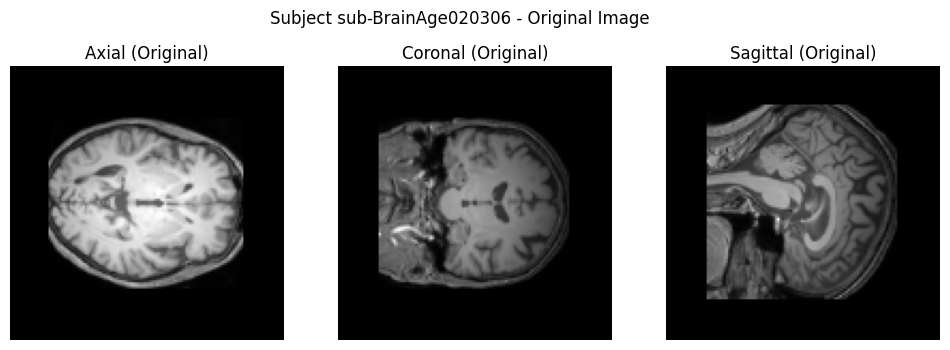

Target: Tuổi đích 25, Giới tính đích Nam


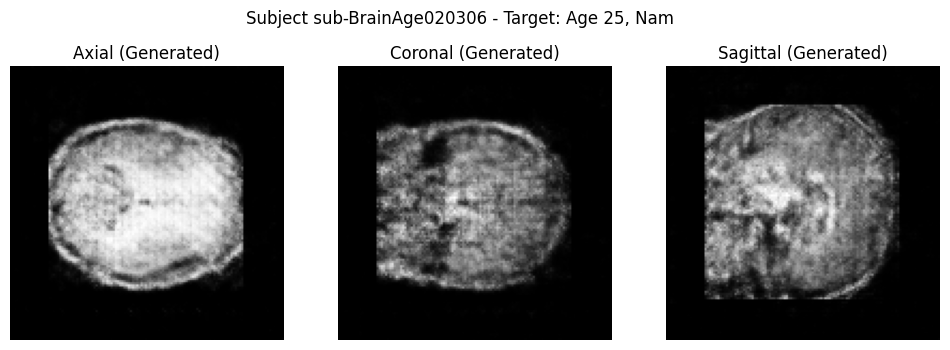

Target: Tuổi đích 25, Giới tính đích Nữ


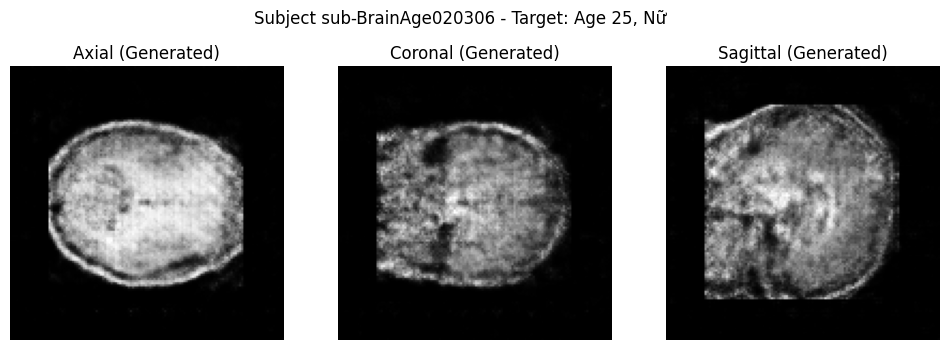

Target: Tuổi đích 50, Giới tính đích Nam


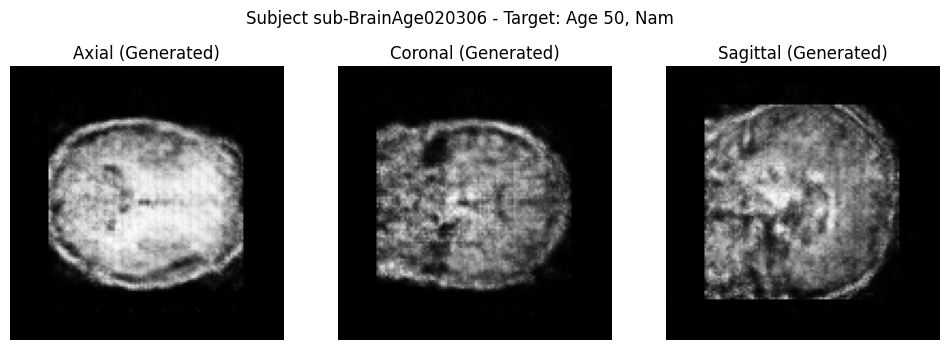

Target: Tuổi đích 50, Giới tính đích Nữ


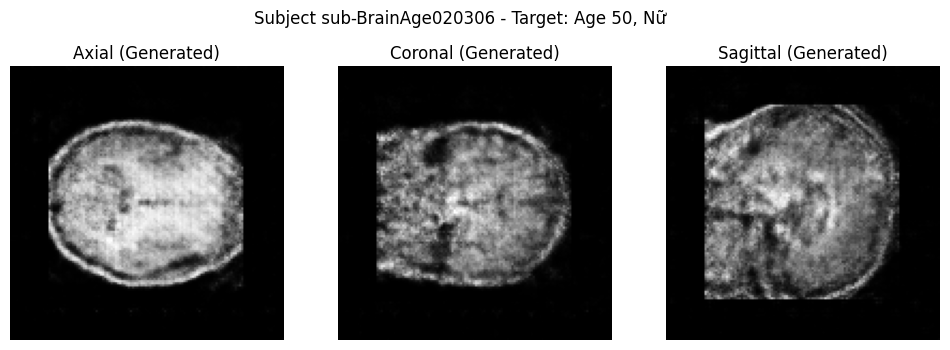


Subject: sub-BrainAge006116
Tuổi gốc: 29.0, Giới tính gốc: Nữ


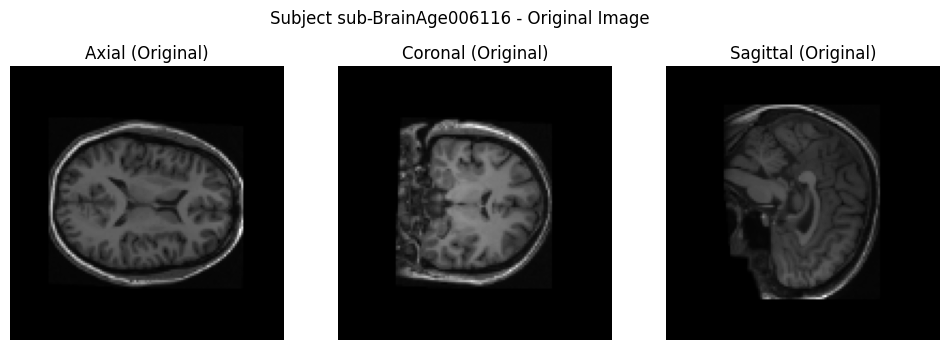

Target: Tuổi đích 25, Giới tính đích Nam


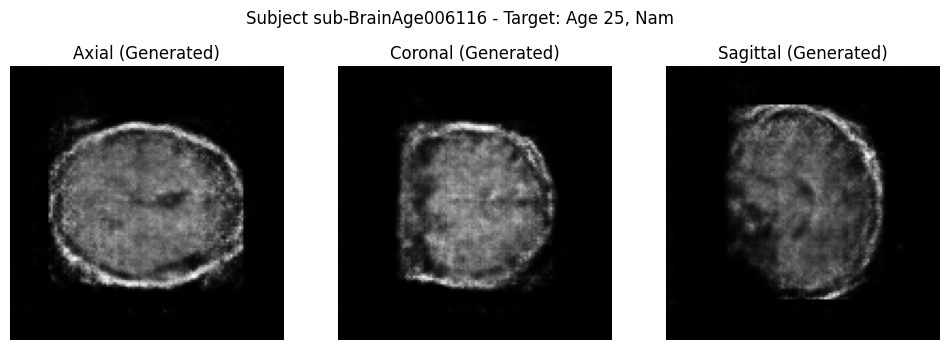

Target: Tuổi đích 25, Giới tính đích Nữ


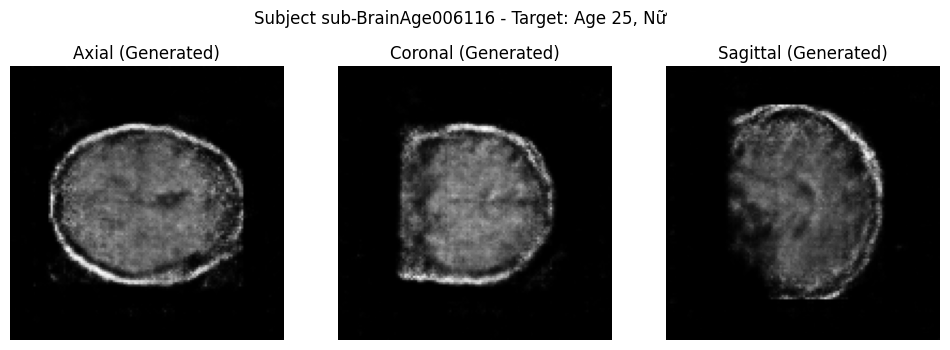

Target: Tuổi đích 50, Giới tính đích Nam


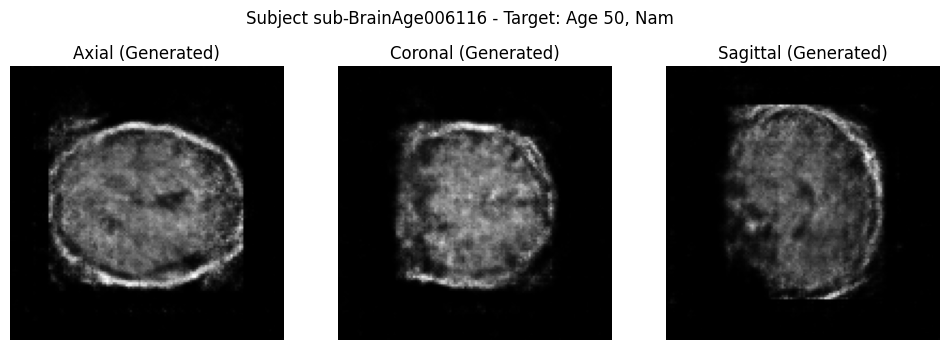

Target: Tuổi đích 50, Giới tính đích Nữ


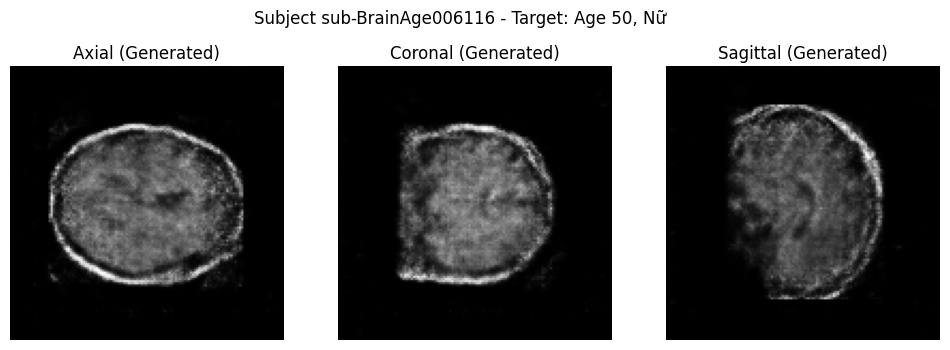


Subject: sub-BrainAge020789
Tuổi gốc: 51.0, Giới tính gốc: Nam


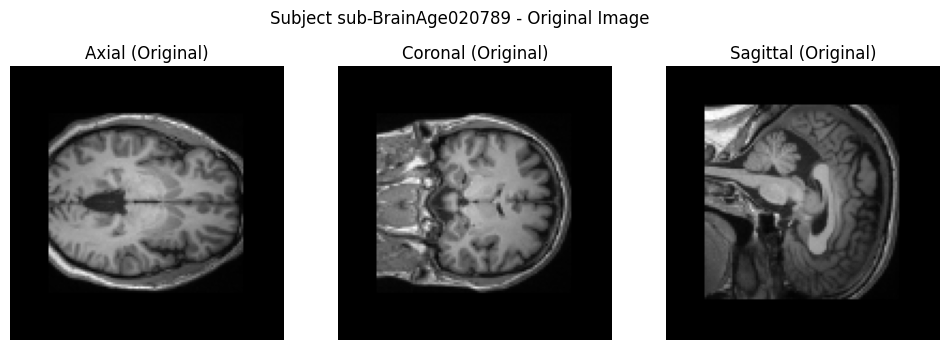

Target: Tuổi đích 25, Giới tính đích Nam


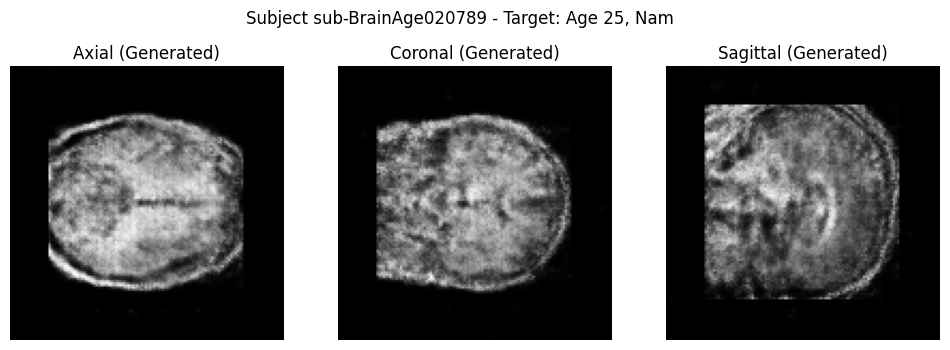

Target: Tuổi đích 25, Giới tính đích Nữ


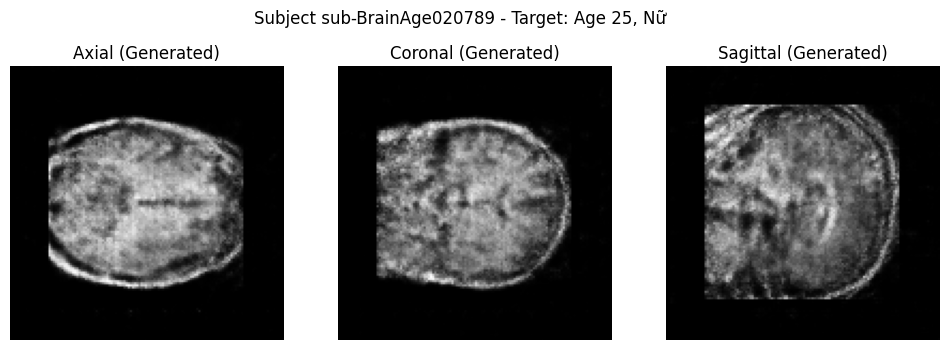

Target: Tuổi đích 50, Giới tính đích Nam


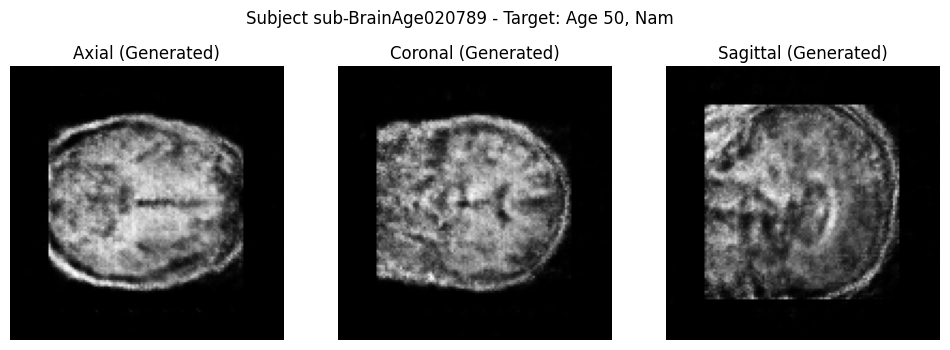

Target: Tuổi đích 50, Giới tính đích Nữ


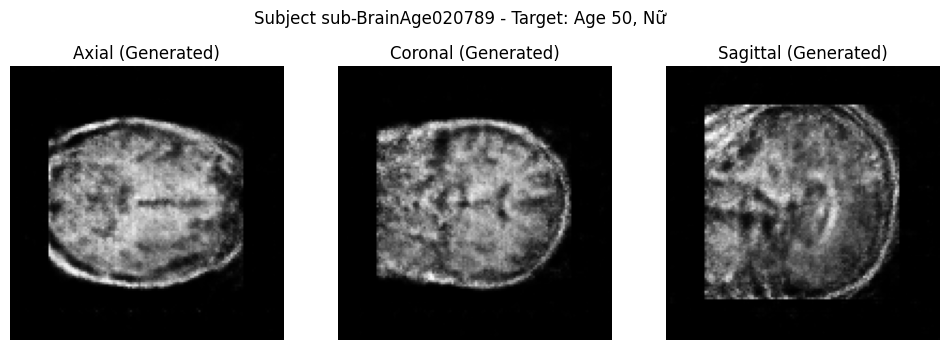


Hoàn thành kiểm tra. Ảnh đánh giá được lưu tại: /kaggle/working/evaluation


In [22]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib
import glob

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Giải phóng VRAM
torch.cuda.empty_cache()

# Định nghĩa Generator (khớp với mô hình mới)
class Generator(nn.Module):
    def __init__(self, condition_dim=4):
        super(Generator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 128),
            nn.ReLU(),
        )
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # 128 -> 64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # 64 -> 128
            nn.Tanh(),
        )
    
    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 128, 1).expand(batch_size, 1, 128, 128)
        x = torch.cat([x, condition], dim=1)  # Shape: (batch_size, 4, 128, 128)
        x = self.encoder(x)
        x = self.decoder(x)  # Shape: (batch_size, 3, 128, 128)
        return x

# Tải dữ liệu
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
preprocessed_dir = "/kaggle/working/processed_mri_slices"

# Đọc thông tin subject từ participants.xlsx
participants_df = pd.read_excel(participants_file)
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Lấy danh sách subject
all_subjects = [d for d in os.listdir(preprocessed_dir) if os.path.isdir(os.path.join(preprocessed_dir, d)) and d.startswith('sub-BrainAge')]
print(f"Tổng số subject: {len(all_subjects)}")

# Chuẩn hóa tuổi
max_age = 100
min_age = 20  # Giả định, điều chỉnh sau khi chạy check_age_range.py

# Hàm tải và xử lý ảnh
def load_and_process_image(subject_id, preprocessed_dir):
    anat_dir = os.path.join(preprocessed_dir, subject_id, "anat")
    axial_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_axial.nii.gz")).get_fdata()[0]  # Shape: (128, 128)
    coronal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_coronal.nii.gz")).get_fdata()[0]
    sagittal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_sagittal.nii.gz")).get_fdata()[0]
    
    combined_slice = np.stack([axial_slice, coronal_slice, sagittal_slice], axis=0)  # Shape: (3, 128, 128)
    combined_tensor = torch.tensor(combined_slice, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 3, 128, 128)
    
    age = subject_info[subject_id]['age'] / max_age
    gender = subject_info[subject_id]['gender']
    condition = torch.tensor([age, gender], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 2)
    
    return combined_slice, combined_tensor, condition, age * max_age, gender

# Tải mô hình
G_A_to_B = Generator().to(device)
G_A_to_B.eval()

# Tìm file mô hình mới nhất
model_files = glob.glob("/kaggle/working/G_A_to_B_epoch_*.pth")
if not model_files:
    raise FileNotFoundError("Không tìm thấy file mô hình nào trong /kaggle/working/")
model_path = max(model_files, key=os.path.getctime)  # Lấy file mới nhất
print(f"Tải mô hình từ: {model_path}")
G_A_to_B.load_state_dict(torch.load(model_path))

# Tạo thư mục lưu ảnh đánh giá
eval_dir = "/kaggle/working/evaluation"
os.makedirs(eval_dir, exist_ok=True)

# Chọn ngẫu nhiên 3 subject để kiểm tra
test_subjects = random.sample(all_subjects, 3)

# Các giá trị tuổi và giới tính mục tiêu
target_conditions = [
    (25, 1),  # Tuổi 25, nam
    (25, 0),  # Tuổi 25, nữ
    (50, 1),  # Tuổi 50, nam
    (50, 0),  # Tuổi 50, nữ
]

# Kiểm tra từng subject
for subject_id in test_subjects:
    # Tải ảnh và thông tin gốc
    real_A_np, real_A_tensor, condition_A, orig_age, orig_gender = load_and_process_image(subject_id, preprocessed_dir)
    real_A_np = (real_A_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1] để hiển thị
    
    # Hiển thị và lưu ảnh gốc
    print(f"\nSubject: {subject_id}")
    print(f"Tuổi gốc: {orig_age:.1f}, Giới tính gốc: {'Nam' if orig_gender == 1 else 'Nữ'}")
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
        axes[i].imshow(real_A_np[i], cmap='gray')
        axes[i].set_title(f"{plane} (Original)")
        axes[i].axis('off')
    plt.suptitle(f"Subject {subject_id} - Original Image")
    plt.savefig(os.path.join(eval_dir, f"subject_{subject_id}_original.png"))
    plt.show()
    plt.close()
    
    # Kiểm tra với từng điều kiện mục tiêu
    for target_age, target_gender in target_conditions:
        if target_age < min_age or target_age > max_age:
            print(f"Bỏ qua target_age {target_age} vì ngoài phạm vi [{min_age}, {max_age}]")
            continue
        target_age_normalized = target_age / max_age
        condition_A_to_B = torch.tensor([
            condition_A[0, 0].item(),  # Tuổi gốc
            condition_A[0, 1].item(),  # Giới tính gốc
            target_age_normalized,     # Tuổi đích
            target_gender              # Giới tính đích
        ], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 4)
        
        # Sinh ảnh giả
        with torch.no_grad():
            fake_B = G_A_to_B(real_A_tensor, condition_A_to_B)  # Shape: (1, 3, 128, 128)
        
        # Chuyển tensor thành numpy để hiển thị
        fake_B_np = fake_B.squeeze(0).cpu().numpy()  # Shape: (3, 128, 128)
        fake_B_np = (fake_B_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1]
        
        # Hiển thị và lưu ảnh sinh ra
        print(f"Target: Tuổi đích {target_age}, Giới tính đích {'Nam' if target_gender == 1 else 'Nữ'}")
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
            axes[i].imshow(fake_B_np[i], cmap='gray')
            axes[i].set_title(f"{plane} (Generated)")
            axes[i].axis('off')
        plt.suptitle(f"Subject {subject_id} - Target: Age {target_age}, {'Nam' if target_gender == 1 else 'Nữ'}")
        plt.savefig(os.path.join(eval_dir, f"subject_{subject_id}_target_age_{target_age}_gender_{'male' if target_gender == 1 else 'female'}.png"))
        plt.show()
        plt.close()

print("\nHoàn thành kiểm tra. Ảnh đánh giá được lưu tại:", eval_dir)

In [9]:
# Vẽ kết quả mẫu
real_A, condition_A = dataset[0]
real_A = real_A.unsqueeze(0).to(device)
condition_A = condition_A.unsqueeze(0).to(device)
target_age = torch.tensor([50.0 / max_age], dtype=torch.float32, device=device)
target_gender = torch.tensor([1.0], dtype=torch.float32, device=device)
condition_A_to_B = torch.tensor([condition_A[0, 0], condition_A[0, 1], target_age, target_gender], dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    fake_B = G_A_to_B(real_A, condition_A_to_B)
fake_B = fake_B.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Generated Axial")
plt.imshow(fake_B[0], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Generated Coronal")
plt.imshow(fake_B[1], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Generated Sagittal")
plt.imshow(fake_B[2], cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/generated_slices.png')
plt.close()

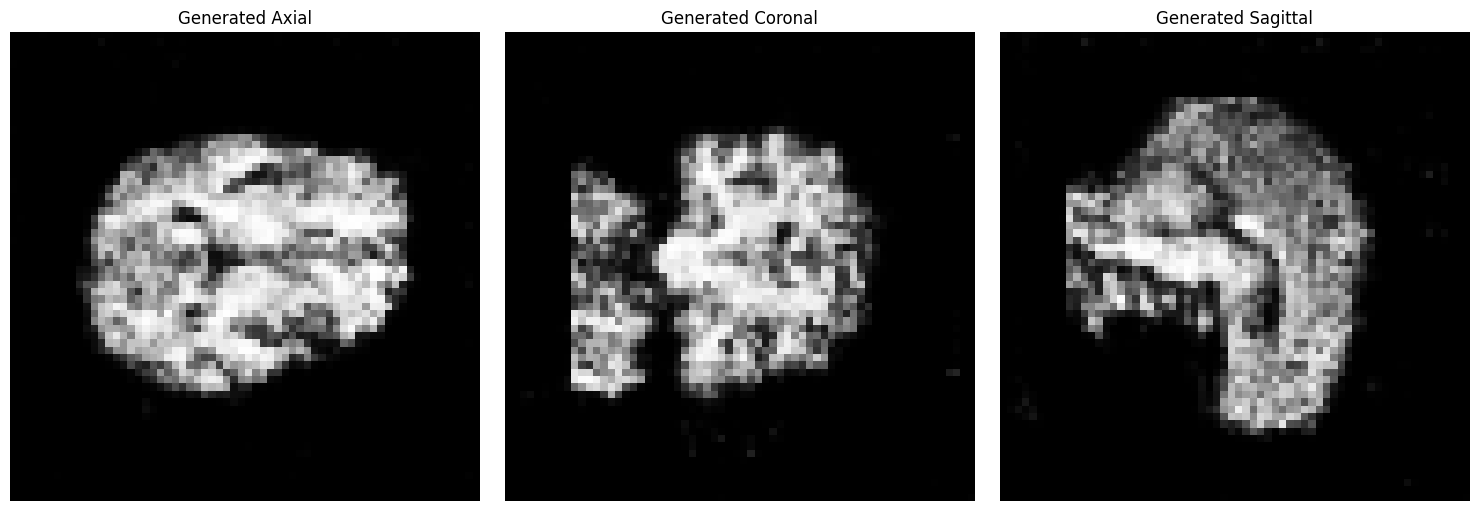

In [12]:
# Vẽ kết quả mẫu
real_A, condition_A = dataset[0]
real_A = real_A.unsqueeze(0).to(device)
condition_A = condition_A.unsqueeze(0).to(device)
target_age = torch.tensor([50.0 / max_age], dtype=torch.float32, device=device)
target_gender = torch.tensor([1.0], dtype=torch.float32, device=device)
condition_A_to_B = torch.tensor([condition_A[0, 0], condition_A[0, 1], target_age, target_gender], dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    fake_B = G_A_to_B(real_A, condition_A_to_B)
fake_B = fake_B.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Generated Axial")
plt.imshow(fake_B[0], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Generated Coronal")
plt.imshow(fake_B[1], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Generated Sagittal")
plt.imshow(fake_B[2], cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/generated_slices.png')
plt.show()
plt.close()

Thiết bị đang sử dụng: cuda
Tổng số subject: 3000
Tải mô hình từ: /kaggle/working/G_A_to_B_epoch_399_batch_0.pth

Subject: sub-BrainAge005472
Tuổi gốc: 45.7, Giới tính gốc: Nam


/tmp/ipykernel_31/2063367579.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G_A_to_B.load_state_dict(torch.load(model_path))


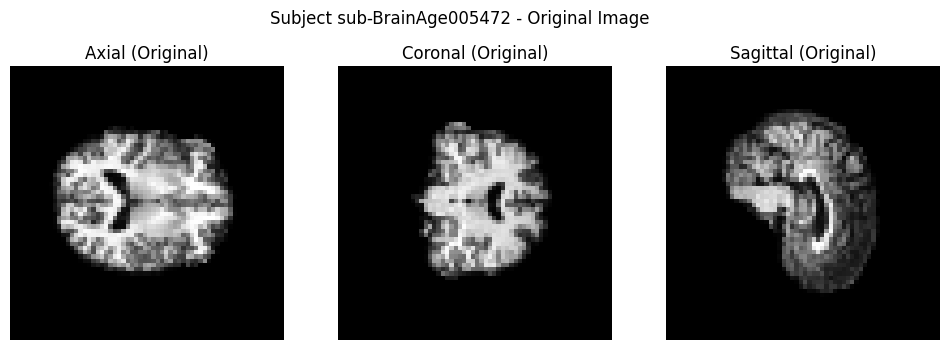

Target: Tuổi đích 25, Giới tính đích Nam


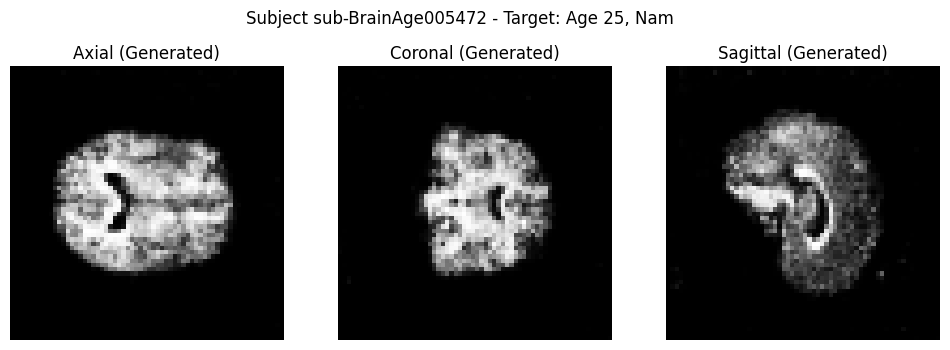

Target: Tuổi đích 25, Giới tính đích Nữ


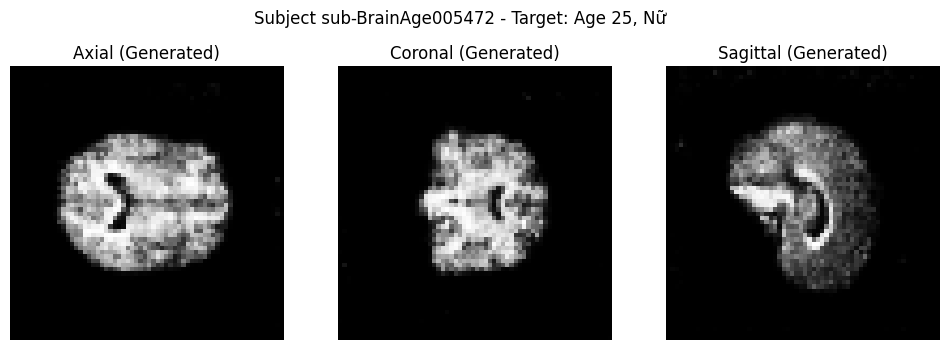

Target: Tuổi đích 50, Giới tính đích Nam


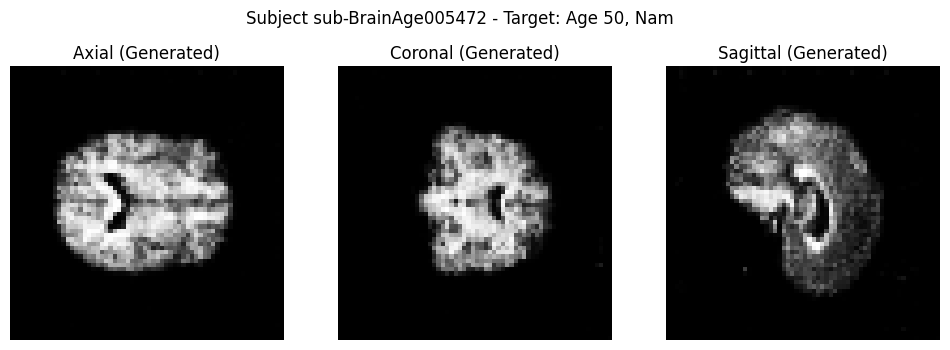

Target: Tuổi đích 50, Giới tính đích Nữ


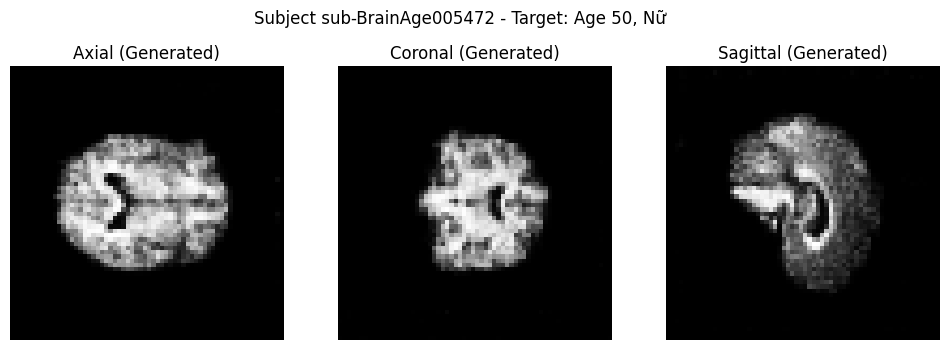


Subject: sub-BrainAge005721
Tuổi gốc: 21.0, Giới tính gốc: Nam


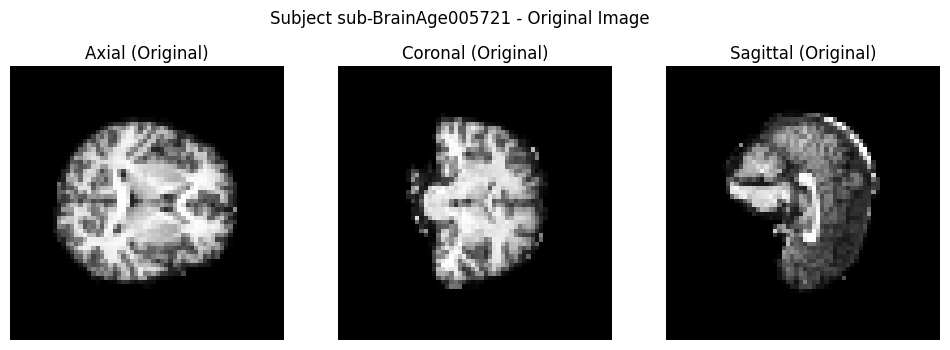

Target: Tuổi đích 25, Giới tính đích Nam


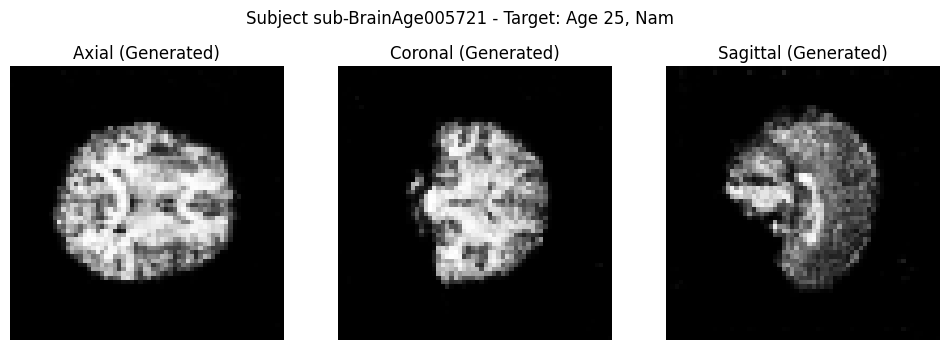

Target: Tuổi đích 25, Giới tính đích Nữ


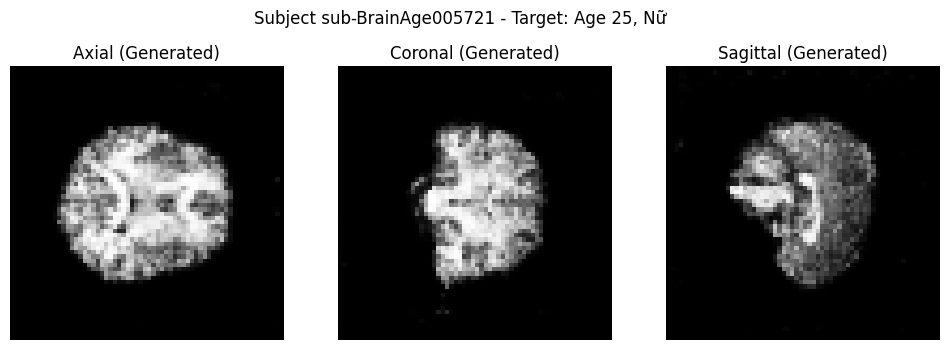

Target: Tuổi đích 50, Giới tính đích Nam


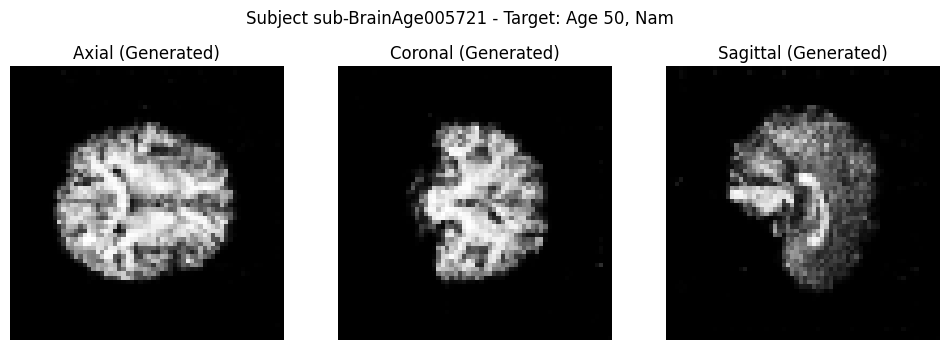

Target: Tuổi đích 50, Giới tính đích Nữ


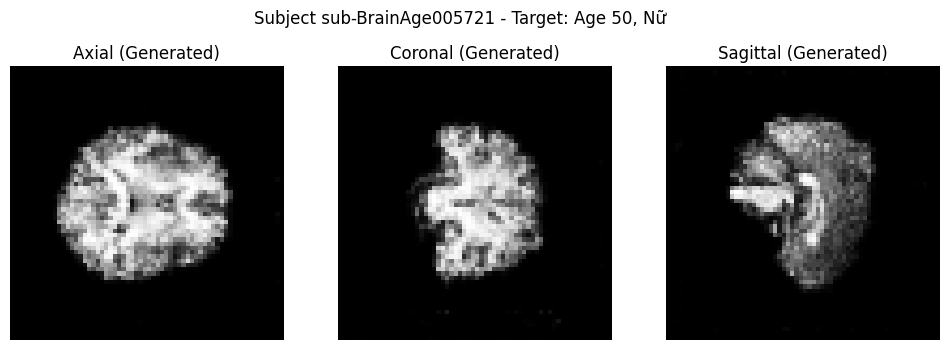


Subject: sub-BrainAge020123
Tuổi gốc: 54.2, Giới tính gốc: Nữ


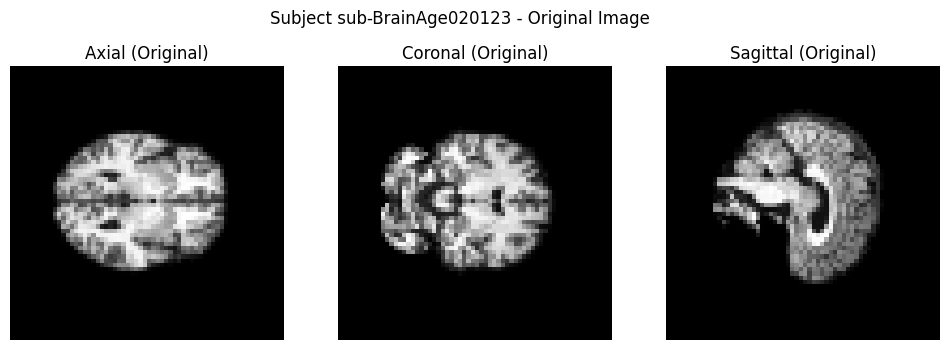

Target: Tuổi đích 25, Giới tính đích Nam


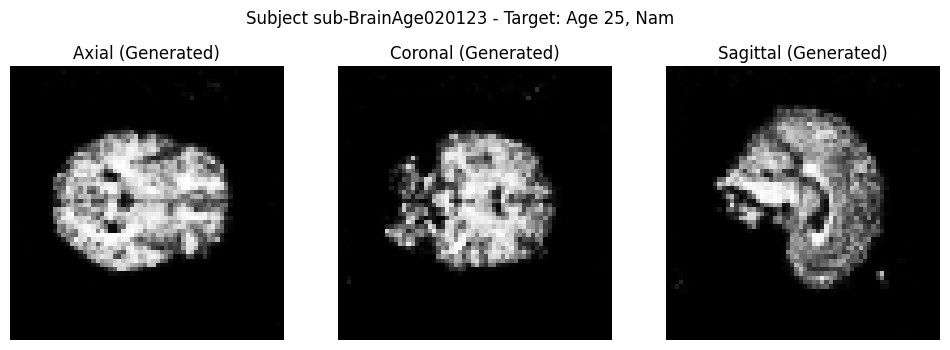

Target: Tuổi đích 25, Giới tính đích Nữ


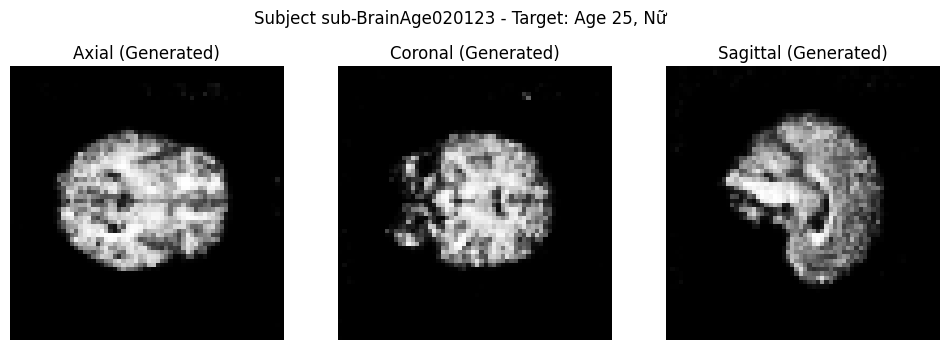

Target: Tuổi đích 50, Giới tính đích Nam


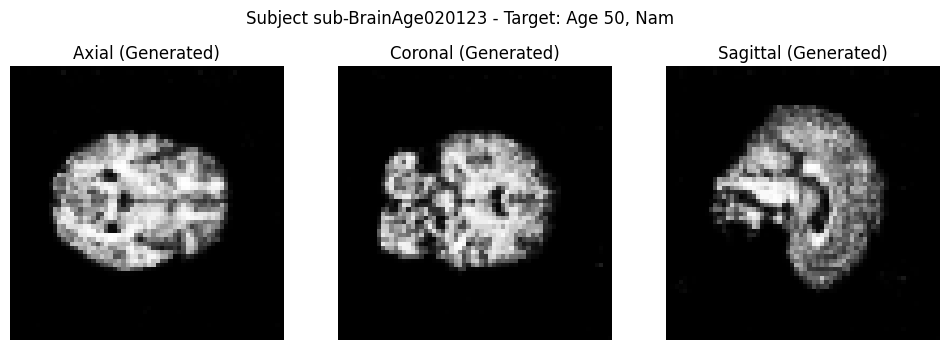

Target: Tuổi đích 50, Giới tính đích Nữ


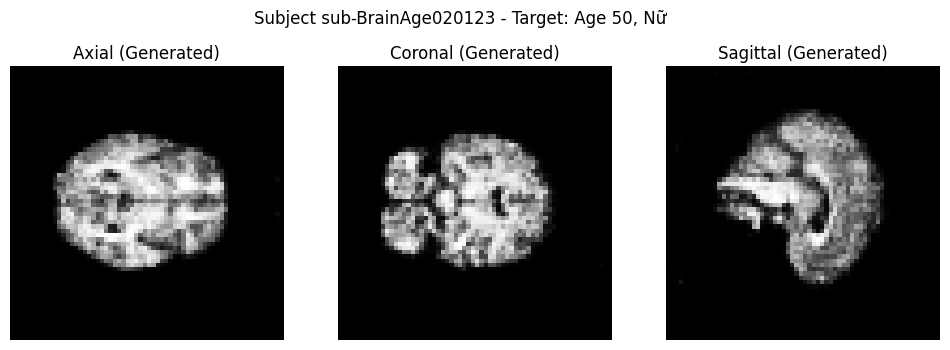


Hoàn thành kiểm tra.


In [13]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Định nghĩa Generator (khớp với mô hình CycleGAN đã huấn luyện)
class Generator(nn.Module):
    def __init__(self, condition_dim=4):
        super(Generator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 64),
            nn.ReLU(),
        )
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # Input: 3 kênh ảnh + 1 kênh condition
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # Output: 3 kênh (axial, coronal, sagittal)
            nn.Tanh(),
        )
    
    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 64, 1).expand(batch_size, 1, 64, 64)
        x = torch.cat([x, condition], dim=1)  # Shape: (batch_size, 4, 64, 64)
        x = self.encoder(x)
        x = self.decoder(x)  # Shape: (batch_size, 3, 64, 64)
        return x

# Tải dữ liệu
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
preprocessed_dir = "/kaggle/working/processed_mri_slices"

# Đọc thông tin subject từ participants.xlsx
participants_df = pd.read_excel(participants_file)
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Lấy danh sách subject
all_subjects = [d for d in os.listdir(preprocessed_dir) if os.path.isdir(os.path.join(preprocessed_dir, d)) and d.startswith('sub-BrainAge')]
print(f"Tổng số subject: {len(all_subjects)}")

# Chuẩn hóa tuổi
max_age = 100

# Hàm tải và xử lý ảnh
def load_and_process_image(subject_id, preprocessed_dir):
    anat_dir = os.path.join(preprocessed_dir, subject_id, "anat")
    axial_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_axial.nii.gz")).get_fdata()[0]  # Shape: (64, 64)
    coronal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_coronal.nii.gz")).get_fdata()[0]
    sagittal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_sagittal.nii.gz")).get_fdata()[0]
    
    combined_slice = np.stack([axial_slice, coronal_slice, sagittal_slice], axis=0)  # Shape: (3, 64, 64)
    combined_tensor = torch.tensor(combined_slice, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 3, 64, 64)
    
    age = subject_info[subject_id]['age'] / max_age
    gender = subject_info[subject_id]['gender']
    condition = torch.tensor([age, gender], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 2)
    
    return combined_slice, combined_tensor, condition, age * max_age, gender

# Tải mô hình
G_A_to_B = Generator().to(device)
G_A_to_B.eval()

model_path = "/kaggle/working/G_A_to_B_epoch_399_batch_0.pth"  # Điều chỉnh epoch/batch nếu cần
print(f"Tải mô hình từ: {model_path}")
if os.path.exists(model_path):
    G_A_to_B.load_state_dict(torch.load(model_path))
else:
    raise FileNotFoundError(f"Không tìm thấy file mô hình tại {model_path}")

# Chọn ngẫu nhiên 3 subject để kiểm tra
test_subjects = random.sample(all_subjects, 3)

# Các giá trị tuổi và giới tính mục tiêu để kiểm tra
target_conditions = [
    (25, 1),  # Tuổi 25, nam
    (25, 0),  # Tuổi 60, nữ
    (50,1),
    (50,0)
]

# Kiểm tra từng subject
for subject_id in test_subjects:
    # Tải ảnh và thông tin gốc
    real_A_np, real_A_tensor, condition_A, orig_age, orig_gender = load_and_process_image(subject_id, preprocessed_dir)
    real_A_np = (real_A_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1] để hiển thị
    
    # Hiển thị ảnh gốc
    print(f"\nSubject: {subject_id}")
    print(f"Tuổi gốc: {orig_age:.1f}, Giới tính gốc: {'Nam' if orig_gender == 1 else 'Nữ'}")
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
        axes[i].imshow(real_A_np[i], cmap='gray')
        axes[i].set_title(f"{plane} (Original)")
        axes[i].axis('off')
    plt.suptitle(f"Subject {subject_id} - Original Image")
    plt.show()
    
    # Kiểm tra với từng điều kiện mục tiêu
    for target_age, target_gender in target_conditions:
        target_age_normalized = target_age / max_age
        condition_A_to_B = torch.tensor([
            condition_A[0, 0].item(),  # Tuổi gốc
            condition_A[0, 1].item(),  # Giới tính gốc
            target_age_normalized,     # Tuổi đích
            target_gender              # Giới tính đích
        ], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 4)
        
        # Sinh ảnh giả
        with torch.no_grad():
            fake_B = G_A_to_B(real_A_tensor, condition_A_to_B)  # Shape: (1, 3, 64, 64)
        
        # Chuyển tensor thành numpy để hiển thị
        fake_B_np = fake_B.squeeze(0).cpu().numpy()  # Shape: (3, 64, 64)
        fake_B_np = (fake_B_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1]
        
        # Hiển thị ảnh sinh ra
        print(f"Target: Tuổi đích {target_age}, Giới tính đích {'Nam' if target_gender == 1 else 'Nữ'}")
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
            axes[i].imshow(fake_B_np[i], cmap='gray')
            axes[i].set_title(f"{plane} (Generated)")
            axes[i].axis('off')
        plt.suptitle(f"Subject {subject_id} - Target: Age {target_age}, {'Nam' if target_gender == 1 else 'Nữ'}")
        plt.show()

print("\nHoàn thành kiểm tra.")


In [16]:
import os
import shutil
import nibabel as nib
import numpy as np
import pandas as pd

# Đường dẫn
data_dir = "/kaggle/working/data_processed"
output_base_dir = "/kaggle/working/processed_mri_slices_128"
participants_file = os.path.join(data_dir, "participants.xlsx")

# Hàm tiền xử lý ảnh 2D
def preprocess_mri_slice(mri_slice):
    # Intensity normalization về [0, 1]
    mri_normalized = (mri_slice - mri_slice.min()) / (mri_slice.max() - mri_slice.min() + 1e-8)  # Tránh chia cho 0
    return mri_normalized

# Tạo danh sách file
file_list = []
for subject_id in os.listdir(data_dir):
    if subject_id.startswith('sub-BrainAge'):
        subject_dir = os.path.join(data_dir, subject_id, "anat")
        file_path = os.path.join(subject_dir, f"{subject_id}_T1w_processed.nii.gz")
        if os.path.exists(file_path):
            file_list.append(file_path)

# Kiểm tra file_list
if not file_list:
    raise ValueError("Không tìm thấy file nào khớp với mẫu *_T1w_processed.nii.gz trong thư mục data_processed!")

# Tạo thư mục đầu ra
os.makedirs(output_base_dir, exist_ok=True)
shutil.copy(participants_file, os.path.join(output_base_dir, "participants.xlsx"))

# Xử lý và lưu 3 mặt cắt 128x128
for idx, file_path in enumerate(file_list):
    subject_id = os.path.basename(os.path.dirname(os.path.dirname(file_path)))
    subject_output_dir = os.path.join(output_base_dir, subject_id, "anat")
    os.makedirs(subject_output_dir, exist_ok=True)
    
    # Đọc ảnh 3D
    mri_img = nib.load(file_path)
    mri_data = mri_img.get_fdata()  # Shape: (130, 130, 130)
    
    # Kiểm tra shape
    if mri_data.shape != (130, 130, 130):
        print(f"Cảnh báo: File {file_path} có shape {mri_data.shape}, không phải (130, 130, 130)")
        continue
    
    # Lấy 3 mặt cắt giữa
    axial_idx = mri_data.shape[2] // 2
    coronal_idx = mri_data.shape[1] // 2
    sagittal_idx = mri_data.shape[0] // 2
    
    axial_slice = mri_data[:, :, axial_idx]  # Shape: (130, 130)
    coronal_slice = mri_data[:, coronal_idx, :]  # Shape: (130, 130)
    sagittal_slice = mri_data[sagittal_idx, :, :]  # Shape: (130, 130)
    
    # Cắt 1 pixel mỗi chiều
    axial_slice = axial_slice[1:-1, 1:-1]  # Shape: (128, 128)
    coronal_slice = coronal_slice[1:-1, 1:-1]
    sagittal_slice = sagittal_slice[1:-1, 1:-1]
    
    # Tiền xử lý
    axial_normalized = preprocess_mri_slice(axial_slice)
    coronal_normalized = preprocess_mri_slice(coronal_slice)
    sagittal_normalized = preprocess_mri_slice(sagittal_slice)
    
    # Chuẩn hóa về [-1, 1]
    axial_final = axial_normalized * 2 - 1
    coronal_final = coronal_normalized * 2 - 1
    sagittal_final = sagittal_normalized * 2 - 1
    
    # Lưu 3 mặt cắt
    for slice_type, slice_data in [
        ('axial', axial_final),
        ('coronal', coronal_final),
        ('sagittal', sagittal_final)
    ]:
        output_file = os.path.join(subject_output_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
        slice_data_3d = slice_data[np.newaxis, :, :]  # Shape: (1, 128, 128)
        nib.save(nib.Nifti1Image(slice_data_3d, np.eye(4)), output_file)
    

print(f"Đã lưu tất cả dữ liệu 128x128 vào: {output_base_dir}")

Đã lưu tất cả dữ liệu 128x128 vào: /kaggle/working/processed_mri_slices_128


Thiết bị đang sử dụng: cuda
Batch 0, Data time: 0.00s, Model time: 0.07s, VRAM: 113.50MB, Loss: 0.8666
Batch 100, Data time: 0.05s, Model time: 6.87s, VRAM: 113.38MB, Loss: 0.0637
Epoch 1, Avg Loss: 0.0937
Batch 0, Data time: 0.00s, Model time: 0.07s, VRAM: 113.50MB, Loss: 0.0544
Batch 100, Data time: 0.05s, Model time: 6.75s, VRAM: 113.38MB, Loss: 0.0446
Epoch 2, Avg Loss: 0.0468
Batch 0, Data time: 0.00s, Model time: 0.07s, VRAM: 113.50MB, Loss: 0.0450
Batch 100, Data time: 0.05s, Model time: 6.75s, VRAM: 113.38MB, Loss: 0.0376
Epoch 3, Avg Loss: 0.0409
Batch 0, Data time: 0.00s, Model time: 0.07s, VRAM: 113.50MB, Loss: 0.0383
Batch 100, Data time: 0.05s, Model time: 6.74s, VRAM: 113.38MB, Loss: 0.0378
Epoch 4, Avg Loss: 0.0385
Batch 0, Data time: 0.00s, Model time: 0.07s, VRAM: 113.50MB, Loss: 0.0372
Batch 100, Data time: 0.05s, Model time: 6.74s, VRAM: 113.38MB, Loss: 0.0351
Epoch 5, Avg Loss: 0.0367
Batch 0, Data time: 0.00s, Model time: 0.07s, VRAM: 113.50MB, Loss: 0.0365
Batch 1

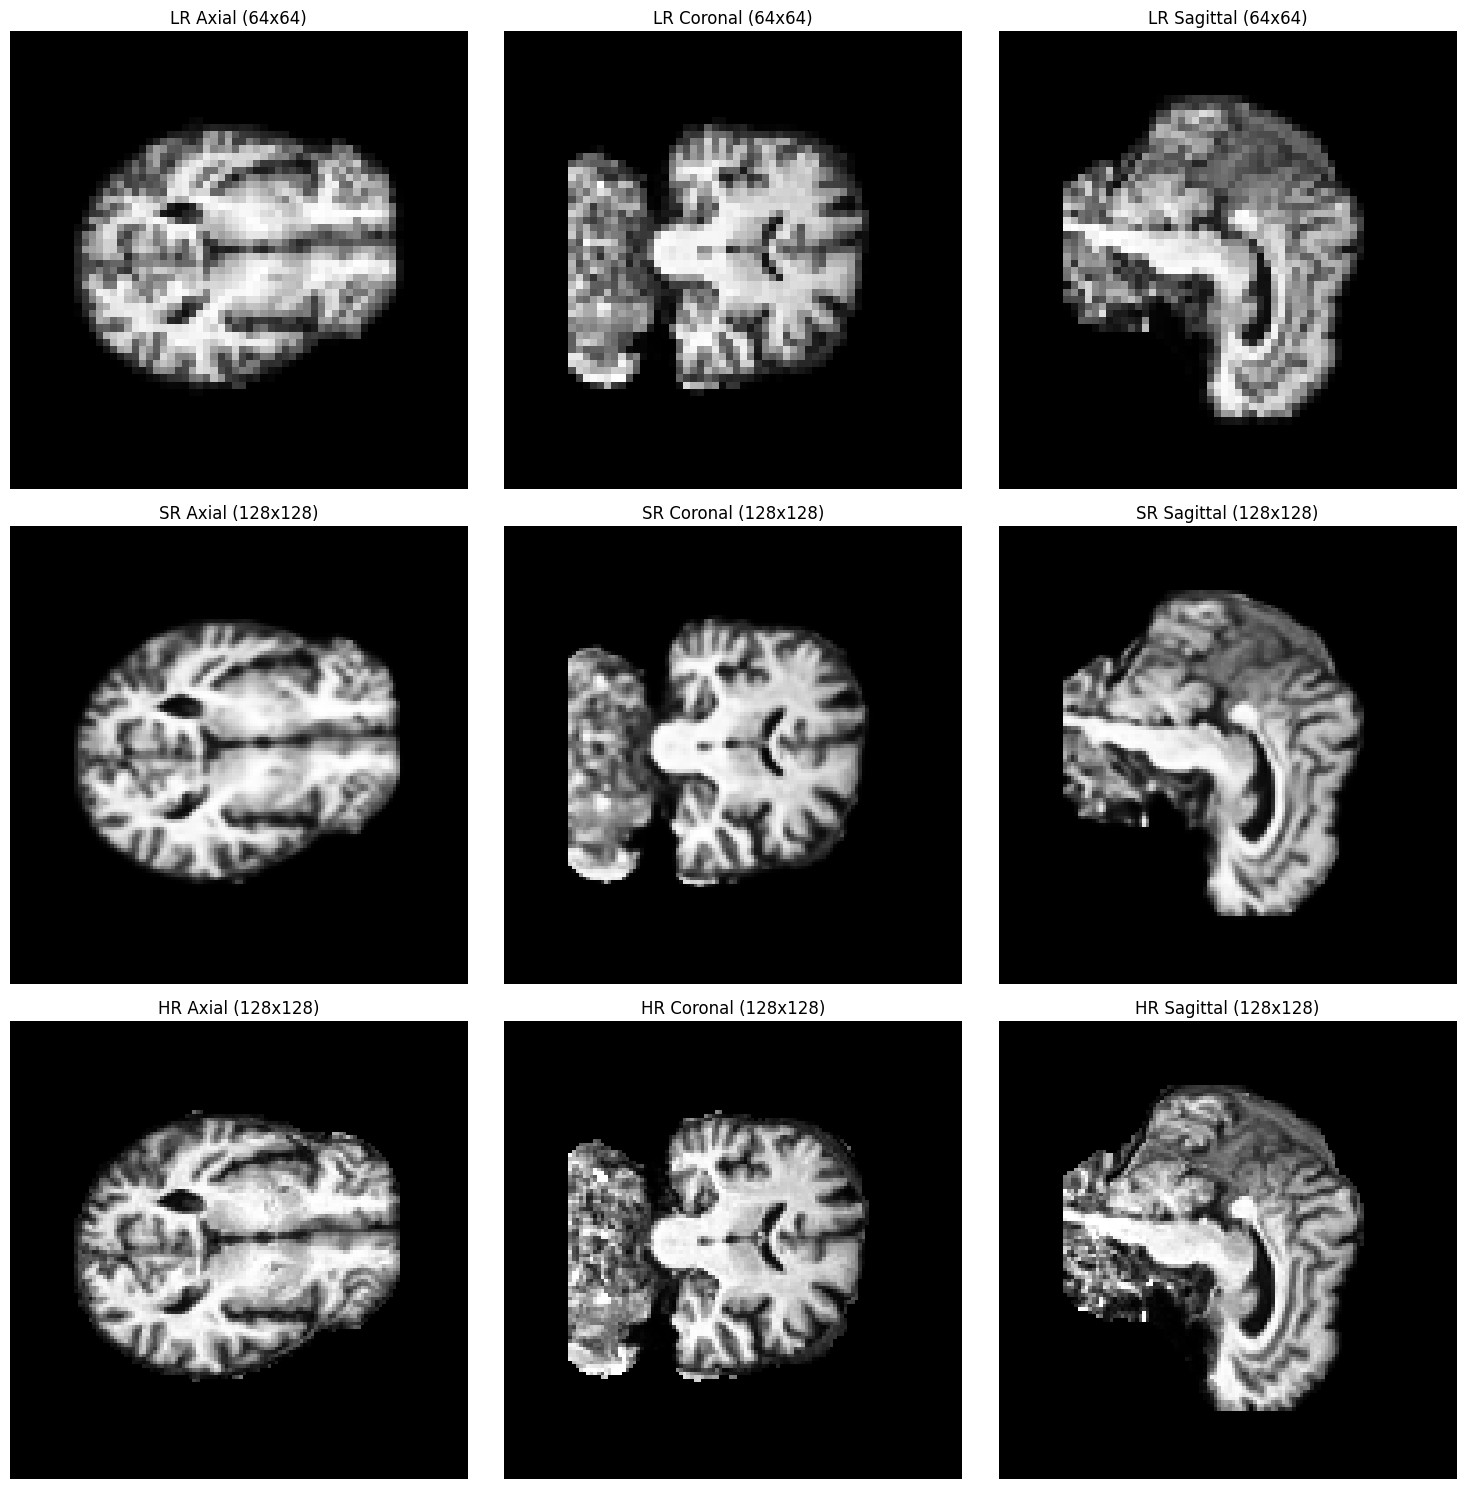

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import nibabel as nib
import pandas as pd
import time
import matplotlib.pyplot as plt

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Dataset cho super-resolution
class SRDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, subjects, target_shape_lr=(64, 64), target_shape_hr=(128, 128)):
        self.lr_dir = lr_dir  # Thư mục ảnh 64x64
        self.hr_dir = hr_dir  # Thư mục ảnh 128x128
        self.subjects = subjects
        self.target_shape_lr = target_shape_lr
        self.target_shape_hr = target_shape_hr
    
    def __len__(self):
        return len(self.subjects)
    
    def __getitem__(self, idx):
        subject_id = self.subjects[idx]
        lr_subject_dir = os.path.join(self.lr_dir, subject_id, "anat")
        hr_subject_dir = os.path.join(self.hr_dir, subject_id, "anat")
        
        # Đọc 3 mặt cắt 64x64 (low-resolution)
        lr_slices = []
        for slice_type in ['axial', 'coronal', 'sagittal']:
            file_path = os.path.join(lr_subject_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
            mri_img = nib.load(file_path)
            mri_data = mri_img.get_fdata()[0]  # Shape: (64, 64)
            lr_slices.append(mri_data)
        lr_tensor = torch.tensor(np.stack(lr_slices), dtype=torch.float32)  # Shape: (3, 64, 64)
        
        # Đọc 3 mặt cắt 128x128 (high-resolution)
        hr_slices = []
        for slice_type in ['axial', 'coronal', 'sagittal']:
            file_path = os.path.join(hr_subject_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
            mri_img = nib.load(file_path)
            mri_data = mri_img.get_fdata()[0]  # Shape: (128, 128)
            hr_slices.append(mri_data)
        hr_tensor = torch.tensor(np.stack(hr_slices), dtype=torch.float32)  # Shape: (3, 128, 128)
        
        return lr_tensor, hr_tensor

# Mô hình SRResNet
class SRResNet(nn.Module):
    def __init__(self, num_residual_blocks=8):
        super(SRResNet, self).__init__()
        
        # Initial convolution
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, stride=1, padding=4),
            nn.PReLU(),
        )
        
        # Residual blocks
        self.res_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(64),
                nn.PReLU(),
                nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(64),
            ) for _ in range(num_residual_blocks)
        ])
        
        # Post-residual convolution
        self.post_res = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
        )
        
        # Upsampling (64x64 -> 128x128)
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1),
            nn.PixelShuffle(upscale_factor=2),  # 64x64 -> 128x128
            nn.PReLU(),
        )
        
        # Final convolution
        self.final = nn.Conv2d(64, 3, kernel_size=9, stride=1, padding=4)
    
    def forward(self, x):
        # Initial feature extraction
        x = self.initial(x)
        
        # Residual blocks
        residual = x
        for res_block in self.res_blocks:
            x = res_block(x) + x  # Skip connection
        x = self.post_res(x) + residual
        
        # Upsampling
        x = self.upsample(x)
        
        # Final output
        x = self.final(x)
        return torch.tanh(x)  # Đầu ra [-1, 1]

# Tạo danh sách subjects
lr_dir = "/kaggle/working/processed_mri_slices"
hr_dir = "/kaggle/working/processed_mri_slices_128"
subjects = [s for s in os.listdir(lr_dir) if s.startswith('sub-BrainAge')]

# Tạo Dataset và DataLoader
dataset = SRDataset(lr_dir, hr_dir, subjects)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

# Khởi tạo mô hình
model = SRResNet().to(device)

# Loss function và optimizer
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.999))

# Mixed precision
scaler = torch.amp.GradScaler('cuda')

# Huấn luyện
epochs = 100
for epoch in range(epochs):
    losses = []
    num_batches = 0
    data_time = 0
    model_time = 0
    
    for i, (lr_images, hr_images) in enumerate(dataloader):
        start_time = time.time()
        lr_images = lr_images.to(device)  # Shape: (batch_size, 3, 64, 64)
        hr_images = hr_images.to(device)  # Shape: (batch_size, 3, 128, 128)
        data_time += time.time() - start_time
        
        optimizer.zero_grad()
        
        model_start = time.time()
        with torch.amp.autocast('cuda'):
            sr_images = model(lr_images)  # Shape: (batch_size, 3, 128, 128)
            loss = criterion(sr_images, hr_images)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        model_time += time.time() - model_start
        
        losses.append(loss.item())
        num_batches += 1
        
        if i % 100 == 0:
            torch.save(model.state_dict(), f"/kaggle/working/sr_model_epoch_{epoch}_batch_{i}.pth")
            print(f"Batch {i}, Data time: {data_time:.2f}s, Model time: {model_time:.2f}s, VRAM: {torch.cuda.memory_allocated() / 1024**2:.2f}MB, Loss: {loss.item():.4f}")
    
    avg_loss = sum(losses) / num_batches if num_batches > 0 else 0
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

# Vẽ kết quả mẫu
lr_images, hr_images = dataset[0]
lr_images = lr_images.unsqueeze(0).to(device)
hr_images = hr_images.unsqueeze(0).to(device)
with torch.no_grad():
    sr_images = model(lr_images)
sr_images = sr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
hr_images = hr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
lr_images = lr_images.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 15))
for j, title in enumerate(["Axial", "Coronal", "Sagittal"]):
    # Low-resolution
    plt.subplot(3, 3, j+1)
    plt.title(f"LR {title} (64x64)")
    plt.imshow(lr_images[j], cmap='gray')
    plt.axis('off')
    # Super-resolution
    plt.subplot(3, 3, j+4)
    plt.title(f"SR {title} (128x128)")
    plt.imshow(sr_images[j], cmap='gray')
    plt.axis('off')
    # High-resolution
    plt.subplot(3, 3, j+7)
    plt.title(f"HR {title} (128x128)")
    plt.imshow(hr_images[j], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sr_sample.png')
plt.show()
plt.close()

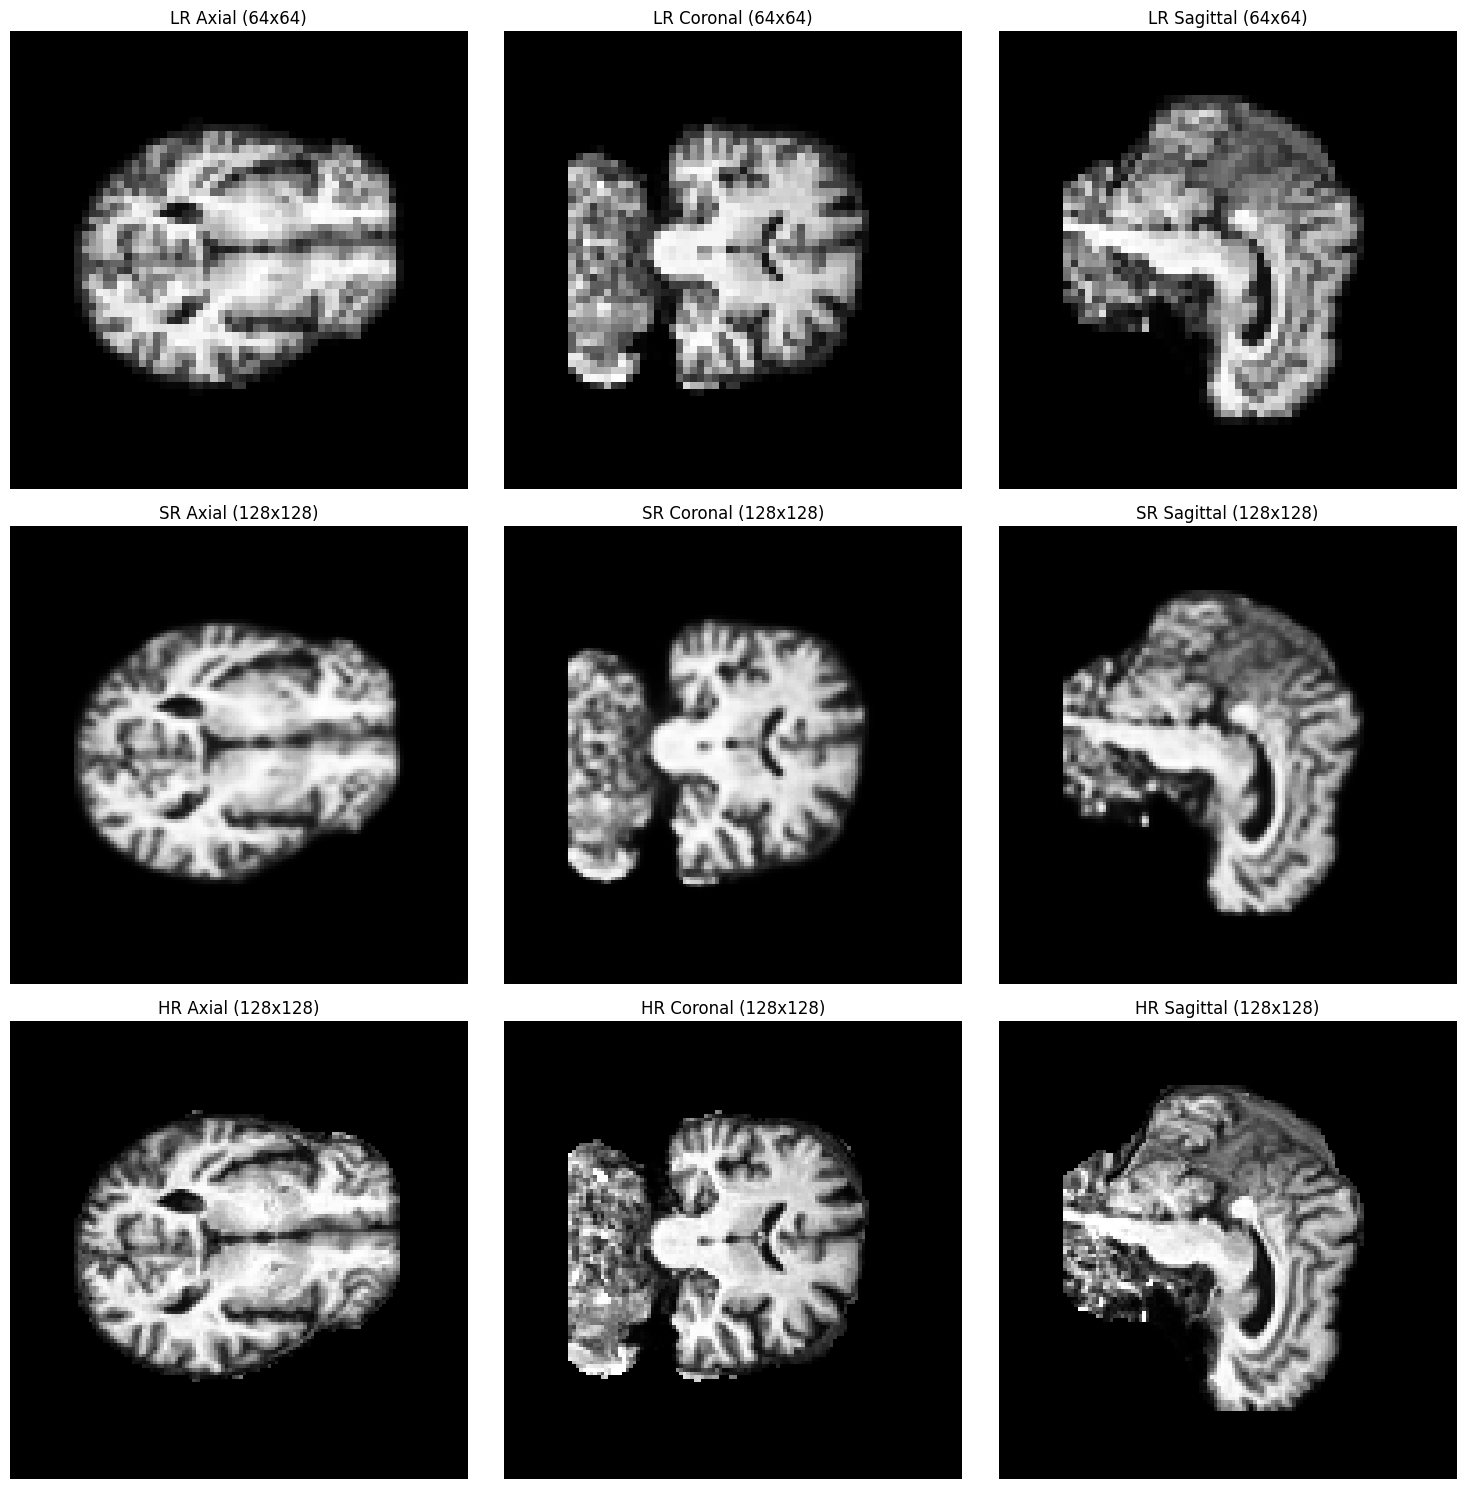

In [18]:
# Vẽ kết quả mẫu
lr_images, hr_images = dataset[0]
lr_images = lr_images.unsqueeze(0).to(device)
hr_images = hr_images.unsqueeze(0).to(device)
with torch.no_grad():
    sr_images = model(lr_images)
sr_images = sr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
hr_images = hr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
lr_images = lr_images.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 15))
for j, title in enumerate(["Axial", "Coronal", "Sagittal"]):
    # Low-resolution
    plt.subplot(3, 3, j+1)
    plt.title(f"LR {title} (64x64)")
    plt.imshow(lr_images[j], cmap='gray')
    plt.axis('off')
    # Super-resolution
    plt.subplot(3, 3, j+4)
    plt.title(f"SR {title} (128x128)")
    plt.imshow(sr_images[j], cmap='gray')
    plt.axis('off')
    # High-resolution
    plt.subplot(3, 3, j+7)
    plt.title(f"HR {title} (128x128)")
    plt.imshow(hr_images[j], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sr_sample.png')
plt.show()
plt.close()